In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, auc
import warnings
warnings.filterwarnings('ignore')

# Load data
columns = ['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'EducationLevel',
           'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore',
           'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'ApprovalStatus']

df = pd.read_csv('crx.data', names=columns, na_values='?', on_bad_lines='skip')

In [5]:
# Data preprocessing
# Handle missing values
df = df.dropna()

# Store original data before encoding for visualizations
df_original = df.copy()

# Ensure ApprovalStatus is correctly formatted
df['ApprovalStatus'] = df['ApprovalStatus'].str.strip()
df['ApprovalStatus'] = df['ApprovalStatus'].map({'+': 1, '-': 0})

# Convert numeric columns
numeric_columns = ['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle categorical variables
categorical_columns = ['Gender', 'Married', 'BankCustomer', 'EducationLevel',
                     'Ethnicity', 'PriorDefault', 'Employed', 'DriversLicense',
                     'Citizen', 'ZipCode']

le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

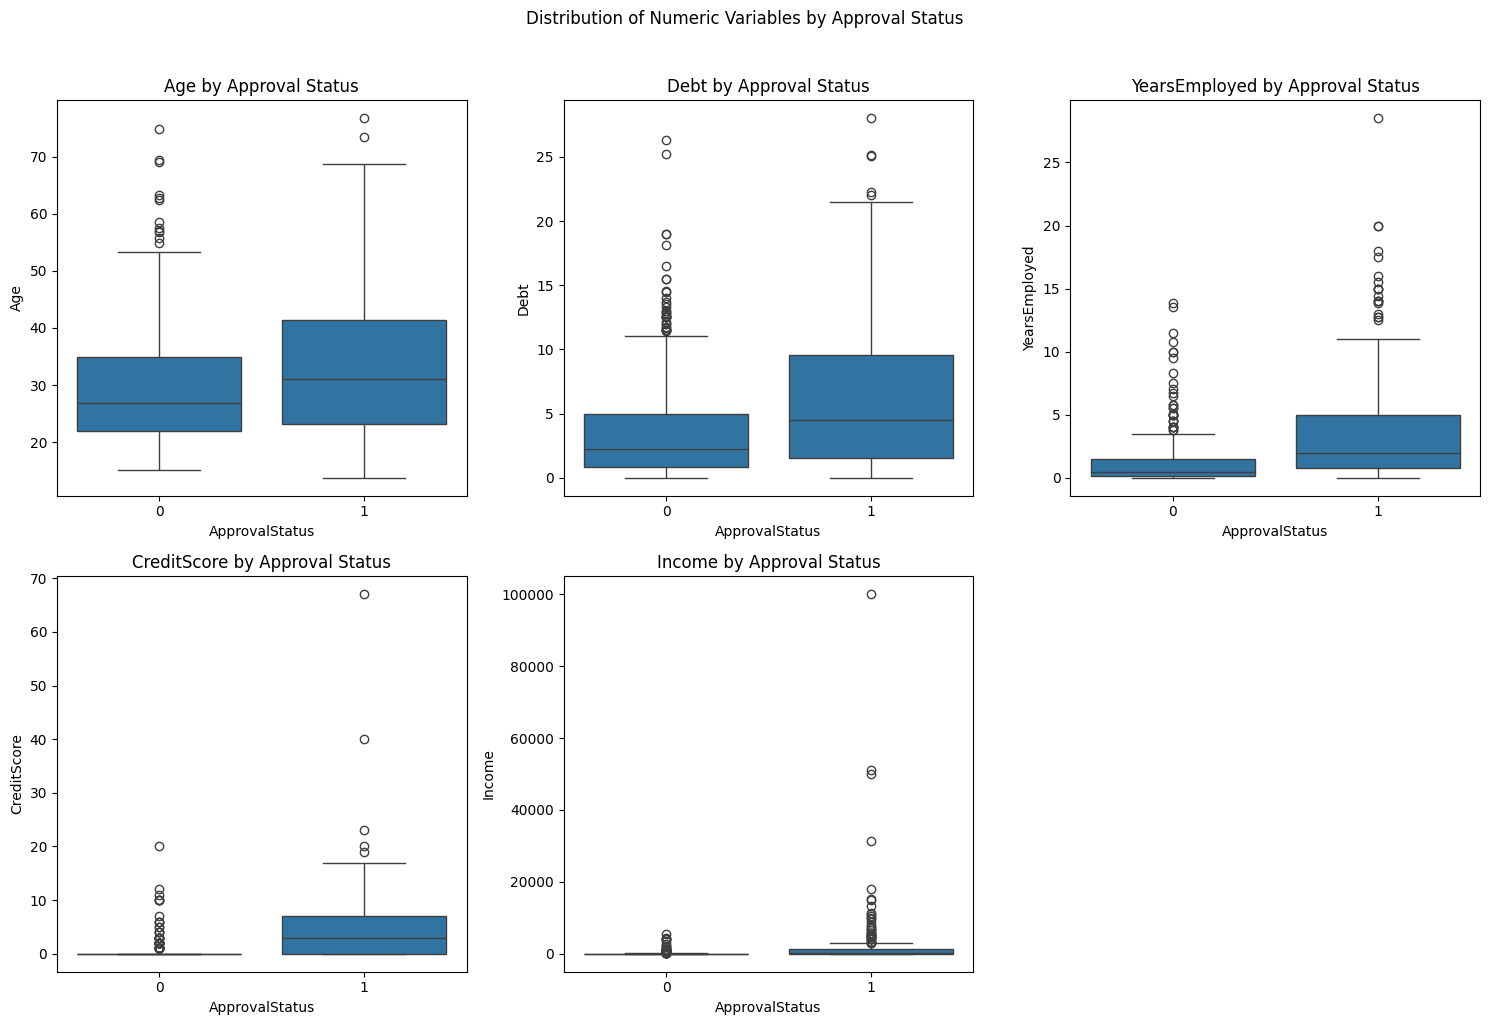

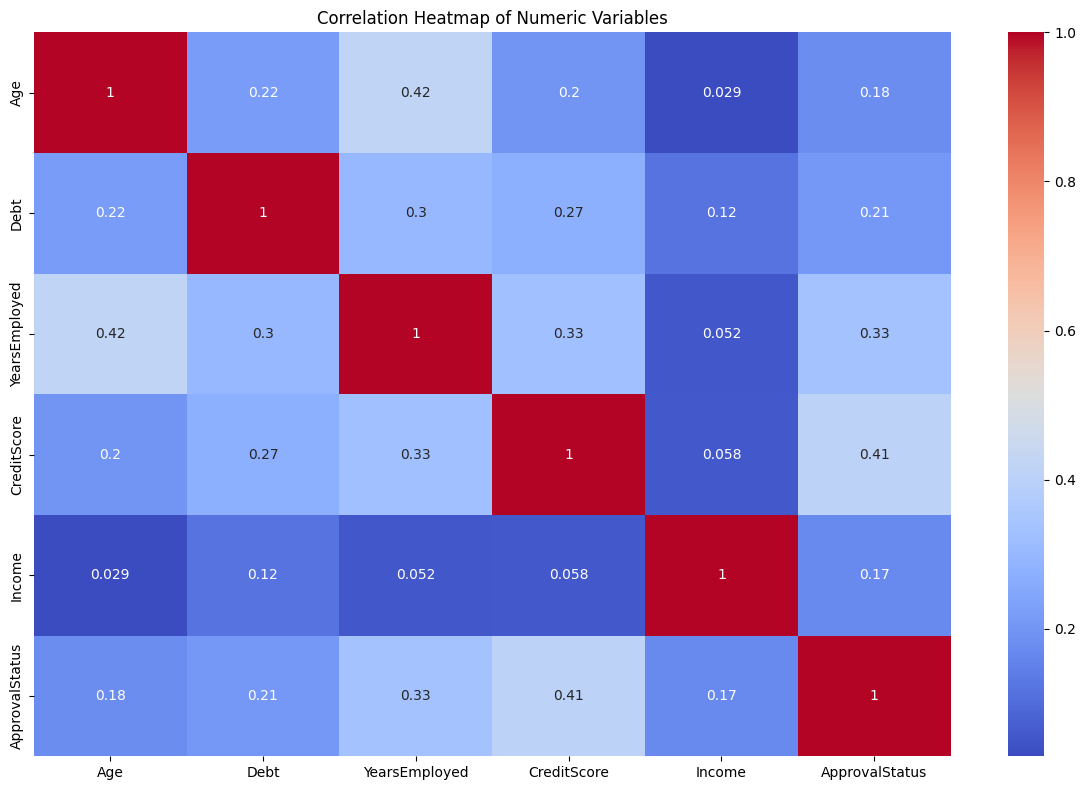

In [7]:
# Additional visualizations before scaling
plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Numeric Variables by Approval Status', y=1.02)

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='ApprovalStatus', y=column, data=df)
    plt.title(f'{column} by Approval Status')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_columns + ['ApprovalStatus']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

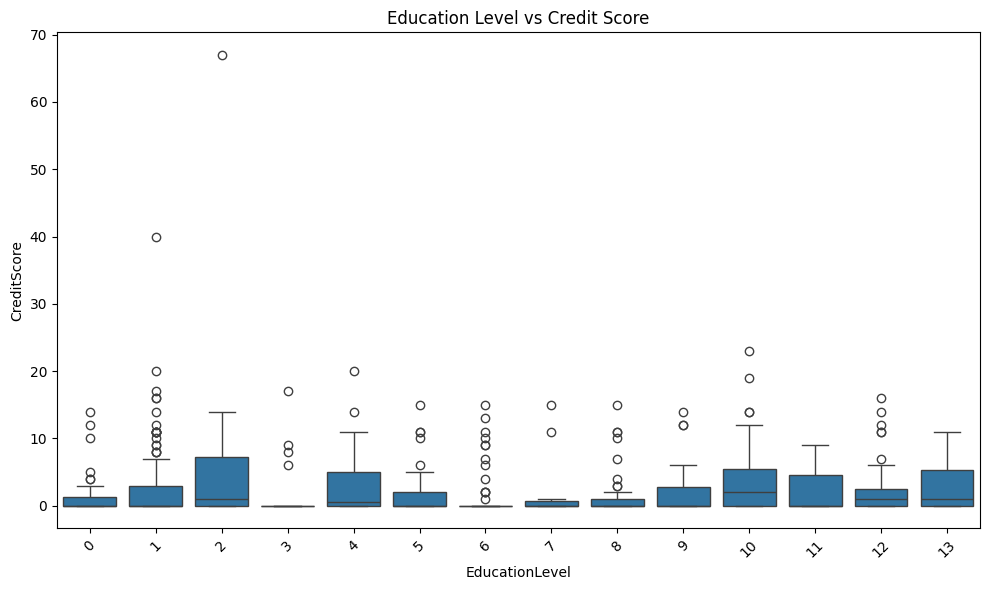

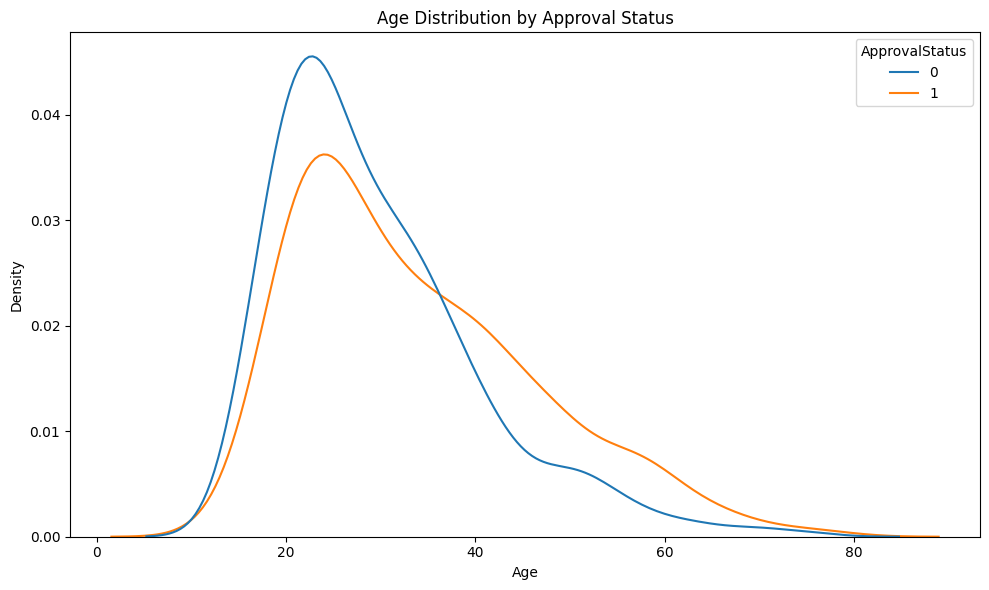

In [8]:
# Education Level vs Credit Score
plt.figure(figsize=(10, 6))
sns.boxplot(x='EducationLevel', y='CreditScore', data=df)
plt.title('Education Level vs Credit Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Age distribution by approval status
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Age', hue='ApprovalStatus', common_norm=False)
plt.title('Age Distribution by Approval Status')
plt.tight_layout()
plt.show()

In [9]:
# Feature scaling for numeric columns
scaler = StandardScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# Split features and target
X = df.drop('ApprovalStatus', axis=1)
y = df['ApprovalStatus']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

In [18]:
# Function to plot learning curves
def plot_learning_curves(model, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10))

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

# Train and evaluate models
results = {}

# Plot ROC curves
plt.figure(figsize=(10, 6))
for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    # Cross validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Cross-validation mean accuracy: {cv_scores.mean():.4f}")
    print("\nClassification Report:")
    print(class_report)


Logistic Regression Results:
Accuracy: 0.8321
Cross-validation mean accuracy: 0.8735

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85        76
           1       0.77      0.85      0.81        55

    accuracy                           0.83       131
   macro avg       0.83      0.84      0.83       131
weighted avg       0.84      0.83      0.83       131


Decision Tree Results:
Accuracy: 0.7786
Cross-validation mean accuracy: 0.8045

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        76
           1       0.75      0.71      0.73        55

    accuracy                           0.78       131
   macro avg       0.77      0.77      0.77       131
weighted avg       0.78      0.78      0.78       131


Random Forest Results:
Accuracy: 0.8550
Cross-validation mean accuracy: 0.8754

Classification Report:
              precision    r

<Figure size 1000x600 with 0 Axes>

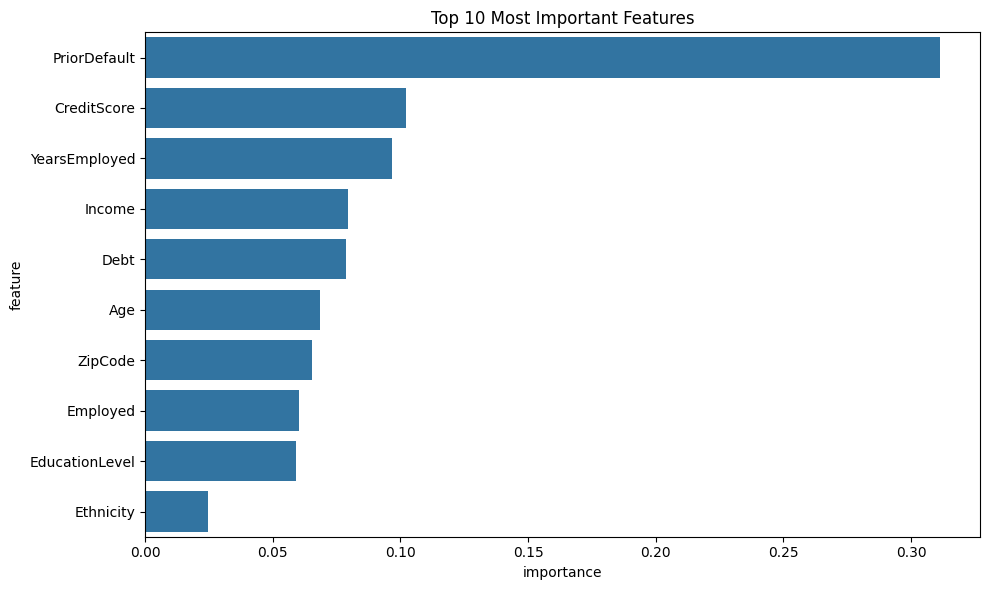

In [19]:
# Feature importance plot (Random Forest)
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

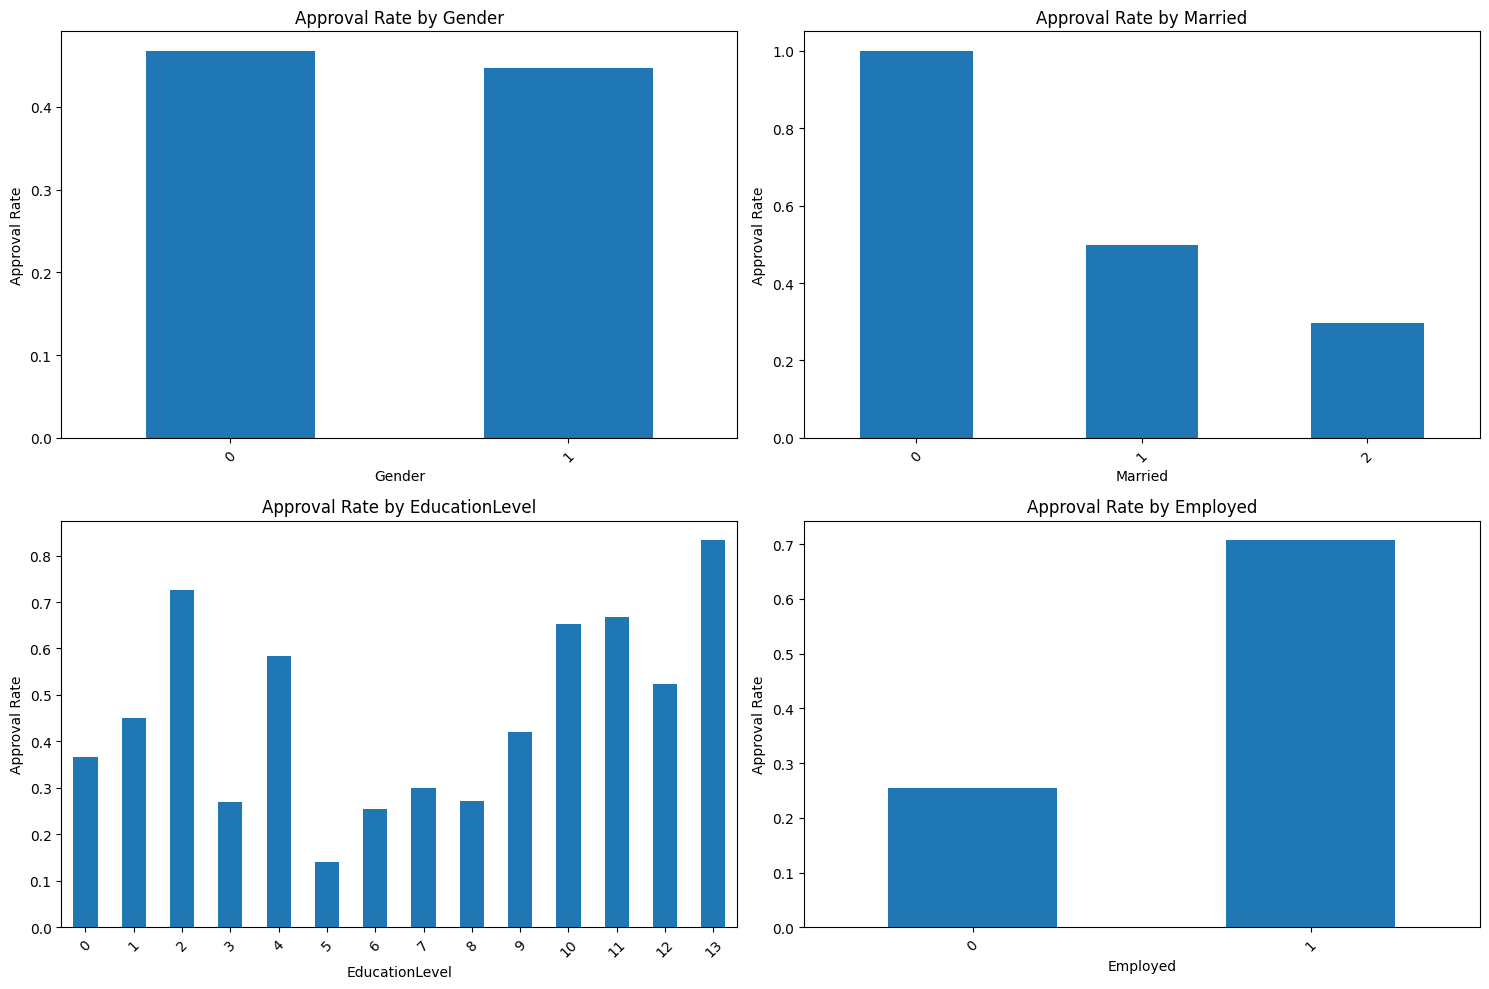

In [15]:
# Analyze approval rates by different categorical variables
categorical_analysis = ['Gender', 'Married', 'EducationLevel', 'Employed']
plt.figure(figsize=(15, 10))
for i, cat in enumerate(categorical_analysis, 1):
    plt.subplot(2, 2, i)
    approval_rates = df.groupby(cat)['ApprovalStatus'].mean()
    approval_rates.plot(kind='bar')
    plt.title(f'Approval Rate by {cat}')
    plt.ylabel('Approval Rate')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

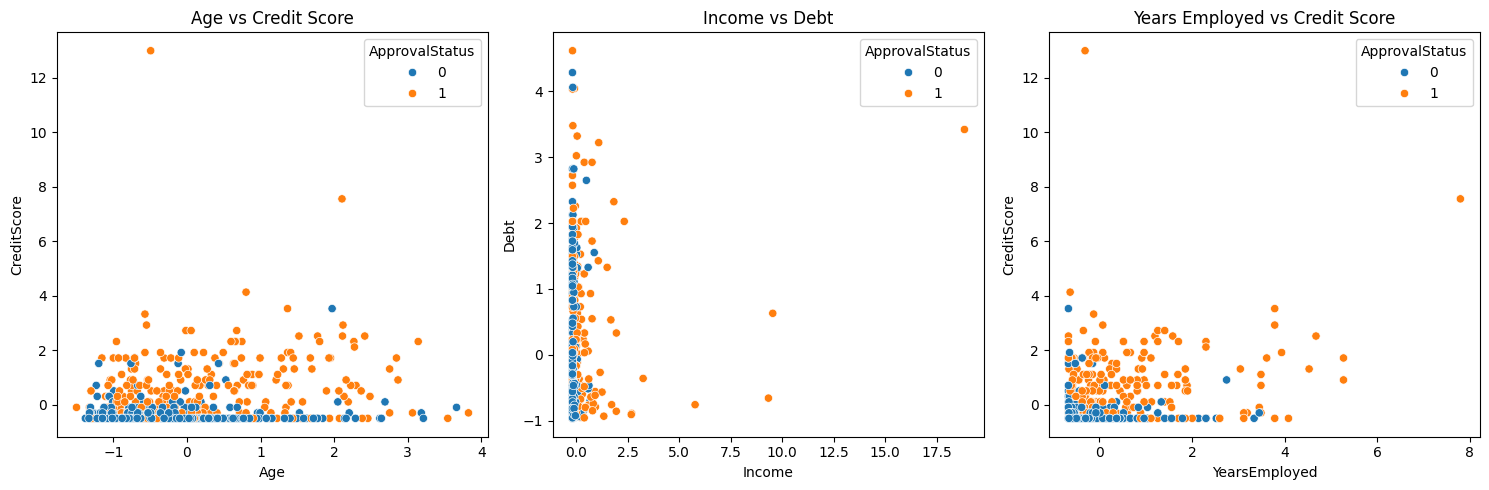

In [16]:
# Bivariate analysis
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='Age', y='CreditScore', hue='ApprovalStatus')
plt.title('Age vs Credit Score')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Income', y='Debt', hue='ApprovalStatus')
plt.title('Income vs Debt')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='YearsEmployed', y='CreditScore', hue='ApprovalStatus')
plt.title('Years Employed vs Credit Score')
plt.tight_layout()
plt.show()